Naive Bayes - Plant Accuracy: 99.55%, Fertilizer Accuracy: 71.36%


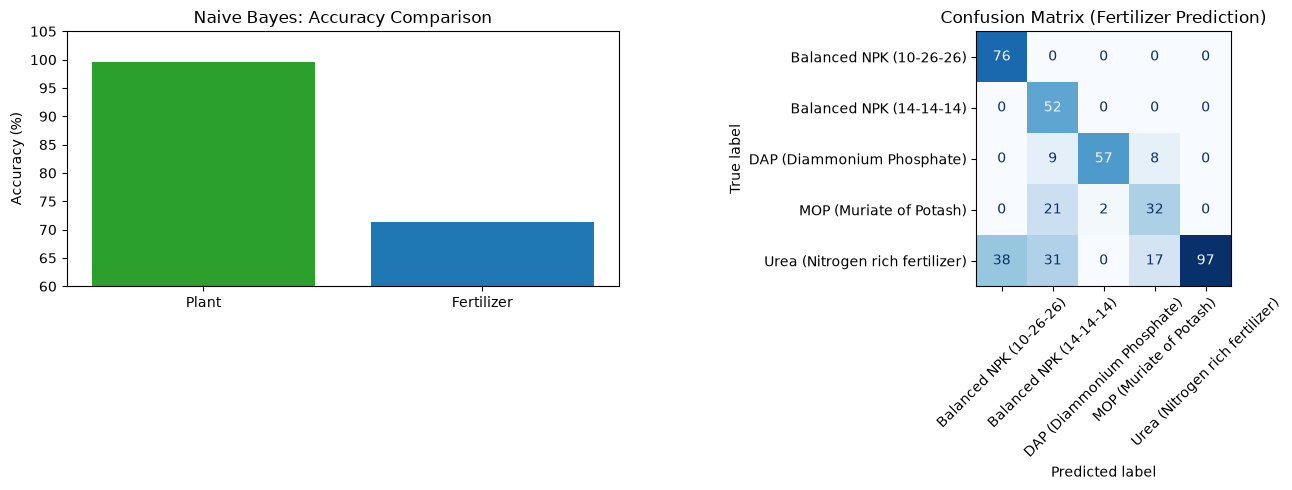

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# --- ข้อมูลที่ 1: ทำนายพืช (Plant.csv) ---
df_plant = pd.read_csv('Plant.csv')
features_plant = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X_p = df_plant[features_plant]
y_p = df_plant['label']
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(X_p, y_p, test_size=0.2, random_state=42, stratify=y_p)

model_plant = GaussianNB()
model_plant.fit(X_p_train, y_p_train)
pred_p = model_plant.predict(X_p_test)
acc_plant = accuracy_score(y_p_test, pred_p) * 100

# --- ข้อมูลที่ 2: ทำนายปุ๋ย (Fertilizer.csv) ---
df_fert = pd.read_csv('Fertilizer.csv')
num_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
cat_cols = ['label']
X_f = df_fert[num_cols + cat_cols]
y_f = df_fert['fertilizer']
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(X_f, y_f, test_size=0.2, random_state=42, stratify=y_f)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])
model_fert = Pipeline([('prep', preprocessor), ('nb', GaussianNB())])
model_fert.fit(X_f_train, y_f_train)
pred_f = model_fert.predict(X_f_test)
acc_fert = accuracy_score(y_f_test, pred_f) * 100

print(f"Naive Bayes - Plant Accuracy: {acc_plant:.2f}%, Fertilizer Accuracy: {acc_fert:.2f}%")

# --- พล็อตกราฟ Confusion Matrix ของ Fertilizer และกราฟ Accuracy ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Plant', 'Fertilizer'], [acc_plant, acc_fert], color=['#2ca02c', '#1f77b4'])
axes[0].set_ylim(60, 105)
axes[0].set_title('Naive Bayes: Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')

ConfusionMatrixDisplay.from_predictions(y_f_test, pred_f, ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (Fertilizer Prediction)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()